# BÀI TẬP TUẦN 4: WEB SCRAPING - THU THẬP & LÀM SẠCH DỮ LIỆU THƯƠNG MẠI ĐIỆN TỬ
### Giảng viên: Bùi Anh Tuấn | Khóa học: Phân tích Dữ liệu với Python
---
### Mục tiêu bài tập (Theo mục 10 - Slide Week 4):
1. **Thu thập danh sách sản phẩm từ một trang thương mại điện tử**: Áp dụng thư viện 
equests và BeautifulSoup để trích xuất dữ liệu đa trang (tên sách, giá tiền, đánh giá sao, tình trạng kho, đường link).
2. **Lưu dữ liệu vào CSV và làm sạch dữ liệu trước khi phân tích**: Chuẩn hóa kiểu dữ liệu số, loại bỏ ký tự tiền tệ, mã hóa nhãn đánh giá và trực quan hóa phân phối bằng pandas, matplotlib, seaborn.
3. **So sánh hai phương pháp Web Scraping: BeautifulSoup vs Scrapy**: Phân tích kiến trúc, hiệu năng, trường hợp sử dụng và cung cấp mã nguồn đối chiếu.


### Step 1. Khai báo các thư viện cần thiết

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings

# Tắt các cảnh báo không cần thiết để giao diện luôn sạch đẹp
warnings.filterwarnings('ignore')

# Thiết lập phong cách đồ họa Seaborn
sns.set_theme(style='whitegrid')
%matplotlib inline
print('Import thư viện thành công!')

Import thư viện thành công!


### Step 2. Phân tích cấu trúc HTML của 1 trang mẫu (Trang 1)
*Trang web thực hành: Books to Scrape (http://books.toscrape.com)*

In [2]:
sample_url = 'http://books.toscrape.com/catalogue/page-1.html'
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}

res = requests.get(sample_url, headers=headers)
print('HTTP Status Code:', res.status_code)

soup = BeautifulSoup(res.text, 'html.parser')
# Tìm cuốn sách đầu tiên trên trang
first_book = soup.find('article', class_='product_pod')

title = first_book.h3.a.get('title')
price = first_book.find('p', class_='price_color').text.strip()
rating_class = [c for c in first_book.find('p', class_='star-rating')['class'] if c != 'star-rating'][0]
stock = first_book.find('p', class_='instock availability').text.strip()

print(f'- Tên sách: {title}')
print(f'- Giá thô: {price}')
print(f'- Xếp hạng sao: {rating_class}')
print(f'- Trạng thái kho: {stock}')

HTTP Status Code: 200
- Tên sách: A Light in the Attic
- Giá thô: Â£51.77
- Xếp hạng sao: Three
- Trạng thái kho: In stock


### Step 3. Thu thập dữ liệu sản phẩm qua 5 trang (Multi-page Crawling)
*Thu thập 100 sản phẩm với độ trễ lịch sự 0.5s giữa các request (Polite Scraping)*

In [3]:
base_url = 'http://books.toscrape.com/catalogue/page-{}.html'
products_list = []
total_pages = 5

for page in range(1, total_pages + 1):
    url = base_url.format(page)
    r = requests.get(url, headers=headers)
    if r.status_code != 200:
        continue
    
    r.encoding = 'utf-8'
    page_soup = BeautifulSoup(r.text, 'html.parser')
    cards = page_soup.find_all('article', class_='product_pod')
    
    for c in cards:
        t = c.h3.a.get('title', '').strip()
        p = c.find('p', class_='price_color').text.strip()
        rc = c.find('p', class_='star-rating').get('class', [])
        r_str = [x for x in rc if x != 'star-rating'][0] if len(rc) > 1 else 'Unknown'
        st = c.find('p', class_='instock availability').text.strip()
        rel_link = c.h3.a.get('href', '')
        full_link = 'http://books.toscrape.com/catalogue/' + rel_link
        
        products_list.append({
            'title': t,
            'price_raw': p,
            'rating_str': r_str,
            'availability_raw': st,
            'url': full_link
        })
    time.sleep(0.5)

df_raw = pd.DataFrame(products_list)
print(f'Thu thập thành công {len(df_raw)} sản phẩm!')
df_raw.head()

Thu thập thành công 100 sản phẩm!


,title,price_raw,rating_str,availability_raw,url
0,A Light in the Attic,£51.77,Three,In stock,http://books.toscrape.com/catalogue/a-light-in...
1,Tipping the Velvet,£53.74,One,In stock,http://books.toscrape.com/catalogue/tipping-th...
2,Soumission,£50.10,One,In stock,http://books.toscrape.com/catalogue/soumission...
3,Sharp Objects,£47.82,Four,In stock,http://books.toscrape.com/catalogue/sharp-obje...
4,Sapiens: A Brief History of Humankind,£54.23,Five,In stock,http://books.toscrape.com/catalogue/sapiens-a-...


### Step 4. Lưu dữ liệu thô vào file CSV (products_raw.csv)

In [4]:
df_raw.to_csv('products_raw.csv', index=False, encoding='utf-8-sig')
print('Đã lưu file products_raw.csv thành công!')

Đã lưu file products_raw.csv thành công!


### Step 5. Làm sạch dữ liệu (Data Cleaning) trước khi phân tích
1. Loại bỏ ký tự tiền tệ (£), chuyển giá sang kiểu số thực (float).
2. Ánh xạ xếp hạng sao dạng chữ (One, Two, Three, Four, Five) sang số nguyên tương ứng từ 1 đến 5 sao.
3. Chuẩn hóa trạng thái tồn kho thành giá trị boolean True/False (In stock -> True).
4. Lưu kết quả dữ liệu sạch ra file `products_cleaned.csv` phục vụ phân tích.

In [5]:
df_clean = df_raw.copy()

# 1. Trích xuất số thực cho giá tiền
df_clean['price_gbp'] = df_clean['price_raw'].str.extract(r'(\d+\.\d+)')[0].astype(float)

# 2. Chuyển đổi xếp hạng sao sang dạng số
rating_dict = {'One': 1, 'Two': 2, 'Three': 3, 'Four': 4, 'Five': 5}
df_clean['rating_stars'] = df_clean['rating_str'].map(rating_dict).fillna(0).astype(int)

# 3. Chuẩn hóa tình trạng kho
df_clean['is_in_stock'] = df_clean['availability_raw'].str.contains('In stock', case=False)

# Giữ lại các cột đã làm sạch
df_clean = df_clean[['title', 'price_gbp', 'rating_stars', 'is_in_stock', 'url']]

# Lưu ra file CSV sạch
df_clean.to_csv('products_cleaned.csv', index=False, encoding='utf-8-sig')
print('Đã lưu file products_cleaned.csv thành công!')
df_clean.head()

Đã lưu file products_cleaned.csv thành công!


,title,price_gbp,rating_stars,is_in_stock,url
0,A Light in the Attic,51.77,3,True,http://books.toscrape.com/catalogue/a-light-in...
1,Tipping the Velvet,53.74,1,True,http://books.toscrape.com/catalogue/tipping-th...
2,Soumission,50.10,1,True,http://books.toscrape.com/catalogue/soumission...
3,Sharp Objects,47.82,4,True,http://books.toscrape.com/catalogue/sharp-obje...
4,Sapiens: A Brief History of Humankind,54.23,5,True,http://books.toscrape.com/catalogue/sapiens-a-...


### Step 6. Phân tích thống kê & Trực quan hóa dữ liệu (EDA)

=== THỐNG KÊ MÔ TẢ GIÁ TIỀN & XẾP HẠNG ===
        price_gbp  rating_stars
count  100.000000    100.000000
mean    34.560700      2.930000
std     14.638531      1.423149
min     10.160000      1.000000
25%     19.897500      2.000000
50%     34.775000      3.000000
75%     47.967500      4.000000
max     58.110000      5.000000


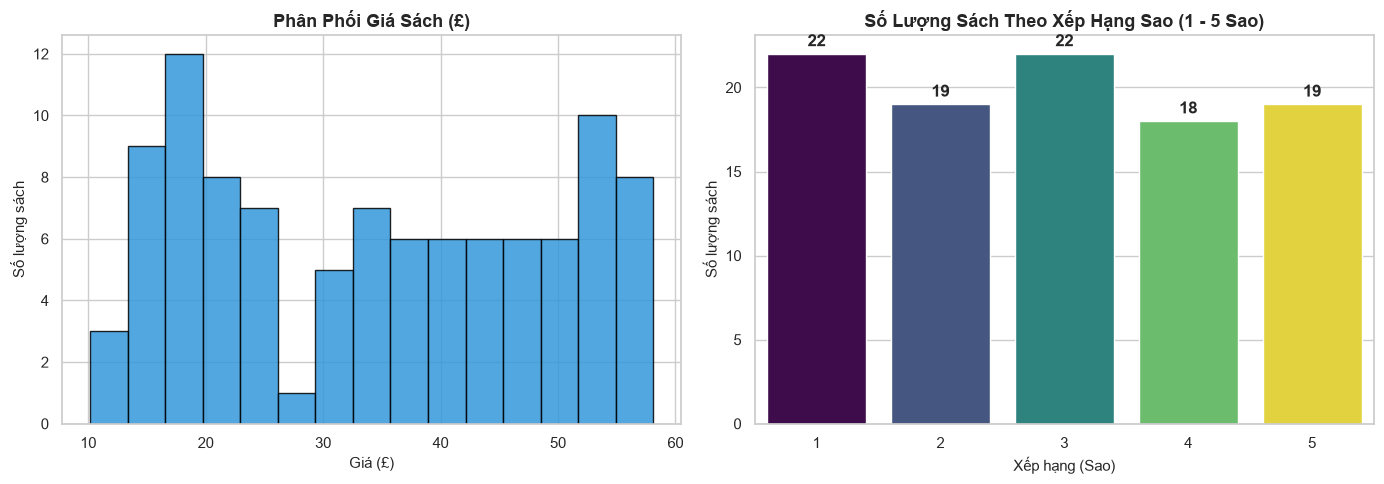

In [6]:
# Bảng thống kê mô tả
print('=== THỐNG KÊ MÔ TẢ GIÁ TIỀN & XẾP HẠNG ===')
print(df_clean[['price_gbp', 'rating_stars']].describe())

# Vẽ biểu đồ phân phối giá sách và xếp hạng sao
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Histogram phân phối giá
axes[0].hist(df_clean['price_gbp'], bins=15, color='#3498db', edgecolor='black', alpha=0.85)
axes[0].set_title('Phân Phối Giá Sách (£)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Giá (£)', fontsize=11)
axes[0].set_ylabel('Số lượng sách', fontsize=11)

# 2. Bar chart xếp hạng sao (Đã gán hue và legend=False để tránh cảnh báo)
rating_counts = df_clean['rating_stars'].value_counts().sort_index()
bar_ax = sns.barplot(
    x=rating_counts.index,
    y=rating_counts.values,
    ax=axes[1],
    hue=rating_counts.index,
    palette='viridis',
    legend=False
)
axes[1].set_title('Số Lượng Sách Theo Xếp Hạng Sao (1 - 5 Sao)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Xếp hạng (Sao)', fontsize=11)
axes[1].set_ylabel('Số lượng sách', fontsize=11)

# Thêm nhãn số lượng trên đầu mỗi cột
for p in bar_ax.patches:
    height = int(p.get_height())
    bar_ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', xytext=(0, 3), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

### Step 7. So sánh hai phương pháp Web Scraping: BeautifulSoup vs Scrapy

Dưới đây là bảng đối chiếu chuyên sâu giữa hai công cụ Web Scraping phổ biến nhất theo 8 tiêu chí kỹ thuật:

| STT | Tiêu chí so sánh | BeautifulSoup (bs4) | Scrapy Framework |
| :---: | :--- | :--- | :--- |
| **1** | **Bản chất kiến trúc** | Thư viện bóc tách cú pháp HTML/XML (Parser). Cần kết hợp với thư viện requests để tải trang web. | Khung ứng dụng thu thập dữ liệu web toàn diện (Full-featured Crawling Framework). |
| **2** | **Hiệu năng & Tốc độ** | **Đơn luồng, tuần tự (Synchronous)**. Mỗi trang phải chờ tải xong mới tới trang tiếp theo, tốc độ chậm khi cào quy mô lớn. | **Bất đồng bộ, đa luồng cực nhanh (Asynchronous)** dựa trên Twisted engine. Xử lý đồng thời hàng trăm request cùng lúc. |
| **3** | **Cấu trúc & Độ phức tạp** | **Rất đơn giản, trực quan**. Viết gọn trong 1 file script hoặc Notebook. Cực kỳ phù hợp cho người mới bắt đầu học. | **Cấu trúc dự án chặt chẽ**. Cần tạo project (scrapy startproject), quản lý thư mục: spiders/, items.py, pipelines.py, settings.py. |
| **4** | **Trích xuất dữ liệu** | Sử dụng các hàm trực quan: `.find()`, `.find_all()`, `.text`, `.get()` hoặc CSS Selectors cơ bản. | Hỗ trợ cả **CSS Selectors** và **XPath** cực mạnh mẽ thông qua công cụ parsel, truy vấn sâu trong cây DOM (`response.css()`, `response.xpath()`). |
| **5** | **Xử lý phân trang & link** | Phải **tự viết code thủ công**: tự tạo vòng lặp URL hoặc tìm thẻ `<a>` để lấy link trang kế tiếp. | **Tự động hóa hoàn toàn**. Sử dụng `response.follow(next_page)` hoặc lớp CrawlSpider tự động quét toàn site theo luật (Rules). |
| **6** | **Khả năng xuất dữ liệu** | Phải tự viết mã lưu file bằng thư viện `csv`, `json` hoặc `pandas.DataFrame.to_csv()`. | **Tích hợp sẵn (Feed Exports)**. Chỉ cần thêm cờ dòng lệnh: `scrapy runspider spider.py -o data.csv` hoặc `-o data.json`. |
| **7** | **Cơ chế chống chặn (Anti-block)** | Không có sẵn; lập trình viên phải tự cấu hình proxy, xoay User-Agent, tự xử lý cookie và session. | Tích hợp sẵn kiến trúc **Middleware**: `AutoThrottle` (tự chỉnh tốc độ theo tải server), User-Agent rotation, tuân thủ `robots.txt`. |
| **8** | **Trường hợp khuyên dùng** | Phân tích dữ liệu nhanh, bài tập học tập, nghiên cứu khoa học, dự án nhỏ và vừa (< 10.000 trang). | Dự án thu thập dữ liệu lớn (hàng triệu trang), hệ thống crawl dữ liệu định kỳ doanh nghiệp, cần tối ưu băng thông và mở rộng. |

---

#### 💡 Tóm tắt kết luận:
- **Nên chọn BeautifulSoup khi:** Bạn cần giải quyết nhanh một bài toán thu thập dữ liệu, làm việc trực tiếp trong Jupyter Notebook, kết hợp liền mạch với Pandas để làm sạch và phân tích dữ liệu ngay lập tức.
- **Nên chọn Scrapy khi:** Bạn xây dựng hệ thống thu thập dữ liệu tự động định kỳ quy mô lớn, cần cào hàng nghìn đến hàng triệu trang web với yêu cầu hiệu năng cao và tự động hóa toàn bộ đường ống dẫn dữ liệu (Data Pipeline).